In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import nltk

# Download necessary NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ndnid\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ndnid\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ndnid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
# Load the data
df = pd.read_excel('C:\\Users\\ndnid\\Desktop\\Reviews.xlsx')

In [12]:
# Convert 'Reviews' column to string type
df['Reviews'] = df['Reviews'].astype(str)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [14]:
# Perform sentiment analysis
df['sentiment_scores'] = df['Reviews'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_scores'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Print the first few rows to verify
print(df[['Reviews', 'sentiment_scores', 'sentiment']].head())

                                             Reviews  sentiment_scores  \
0  Lots of fun activities and the instructors are...            0.8847   
1  It has been an incredible and hugely beneficia...            0.4927   
2  The course struck a fantastic balance between ...            0.7096   
3  Provides a break from PhD and you get to conne...            0.0000   
4                    Once in a lifetime opportunity             0.4215   

  sentiment  
0  Positive  
1  Positive  
2  Positive  
3   Neutral  
4  Positive  


In [39]:
#Create a custom list of stop words
custom_stop_words = set(stopwords.words('english'))
custom_stop_words.update(['would', 'could', 'well', 'us', 'also', 'really'])  # Add more words as needed

# Function to create word cloud
def create_wordcloud(text, title):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())
    filtered_words = [word for word in words if word.isalnum() and word not in stop_words]
    
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(filtered_words))
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout(pad=0)
    plt.show()

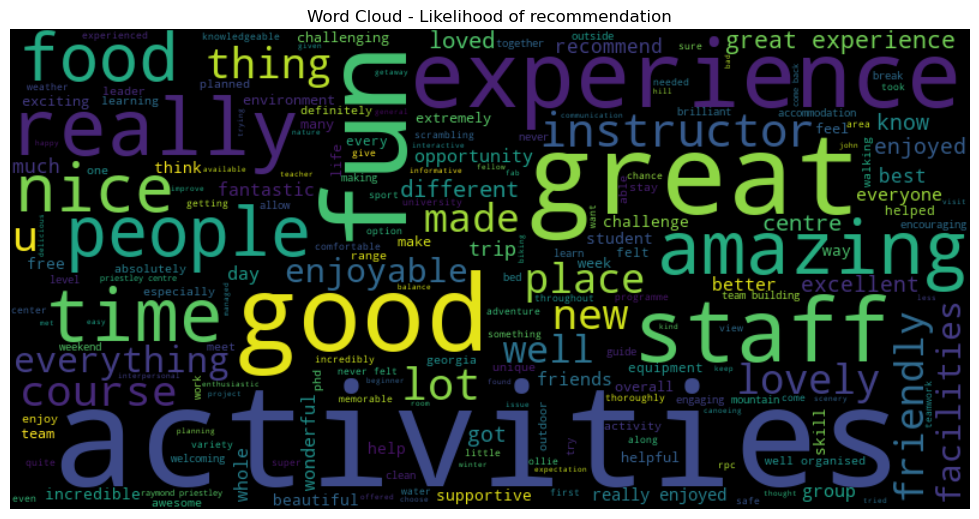

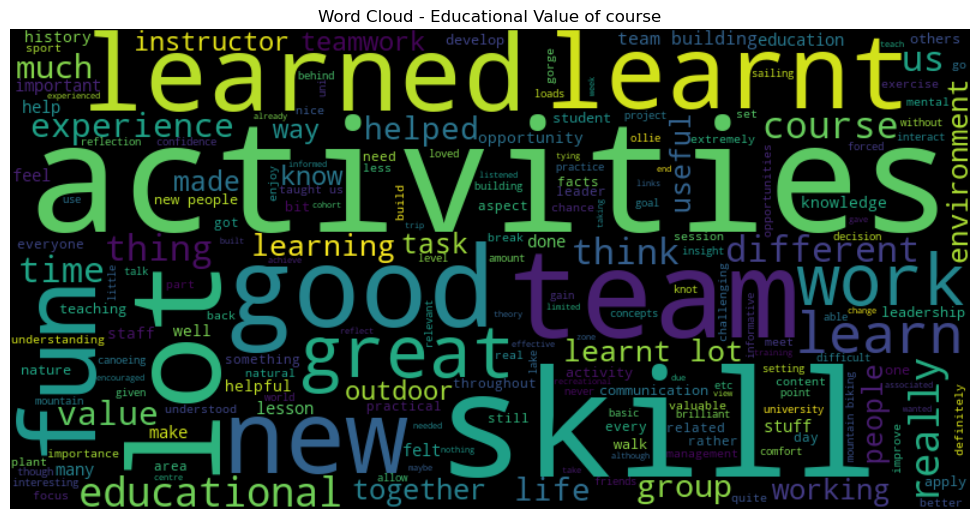

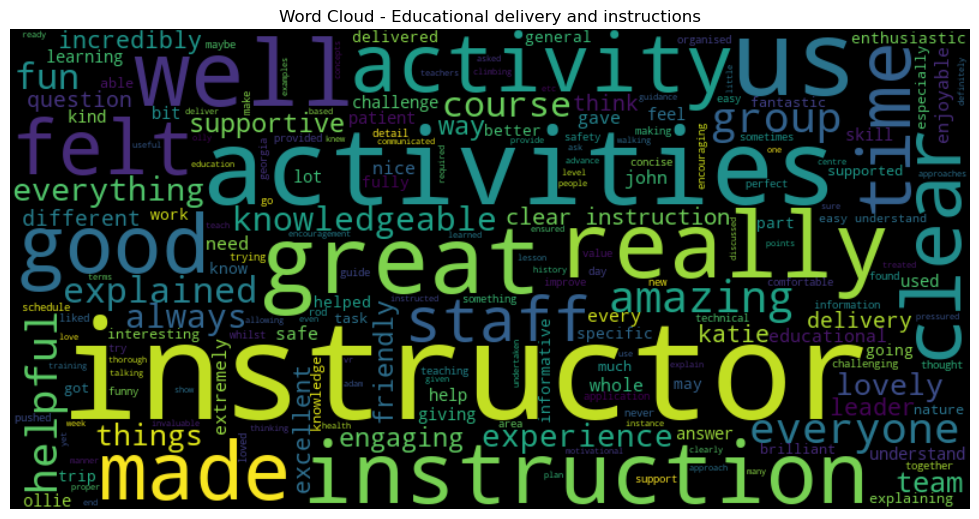

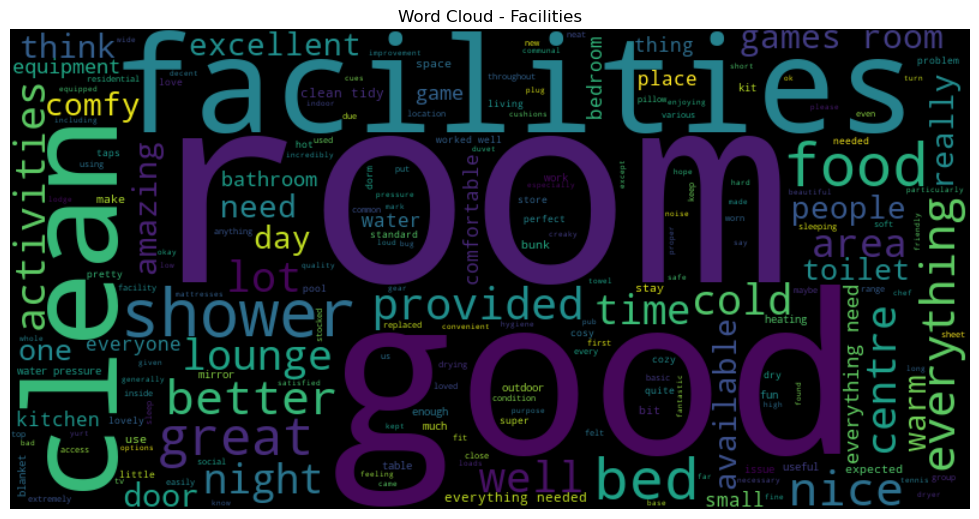

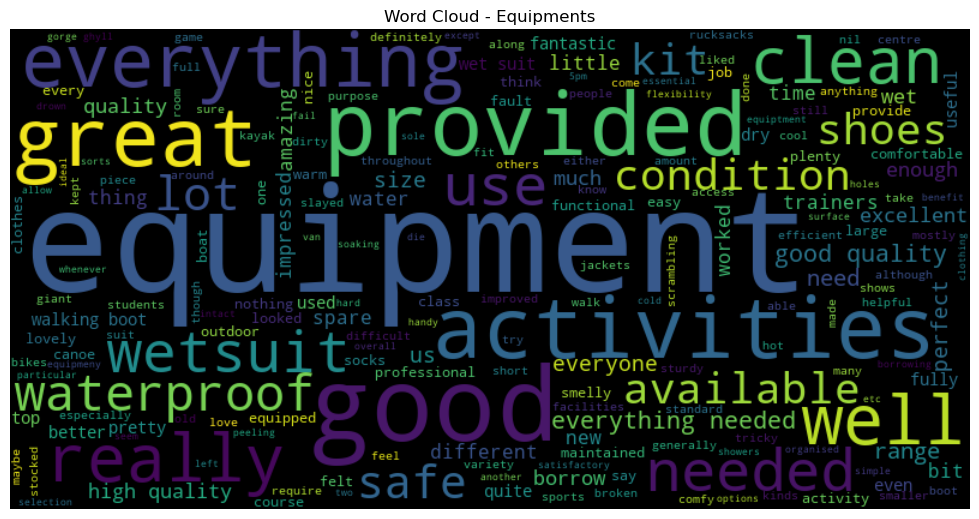

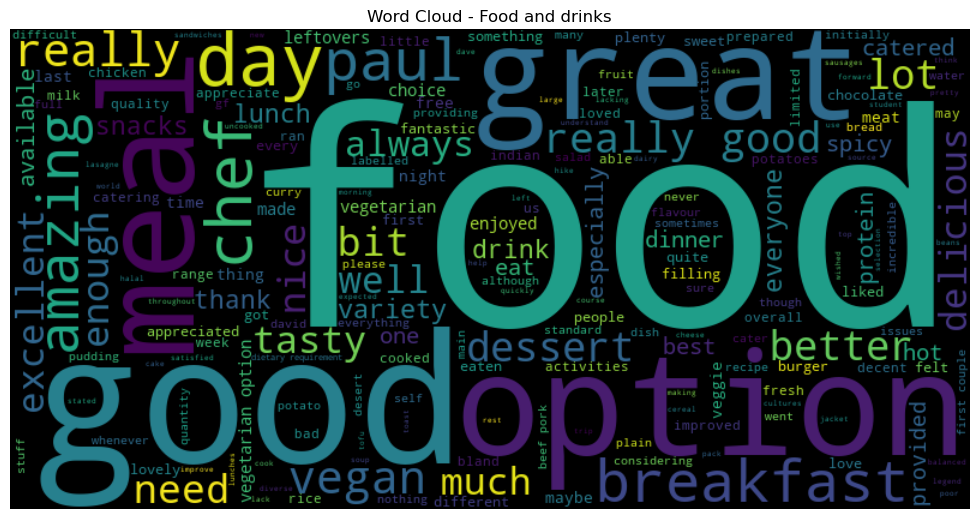

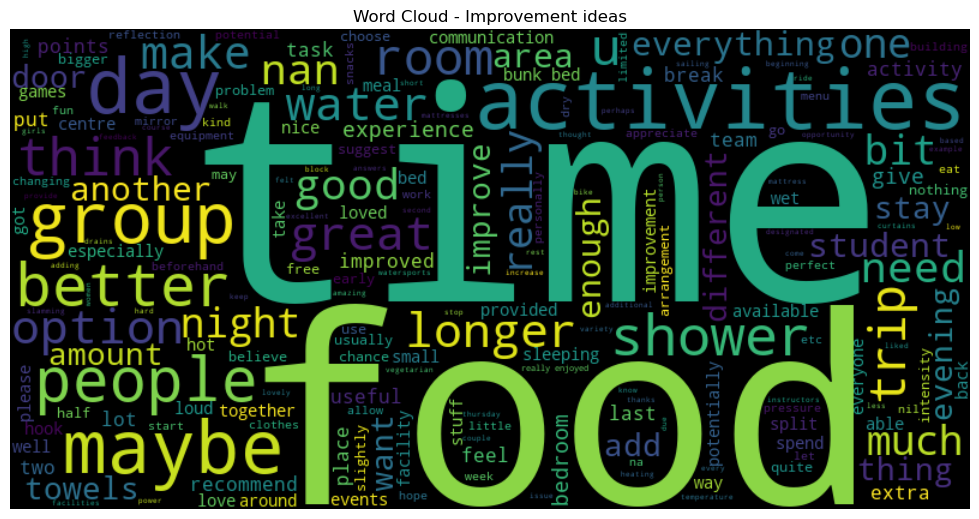

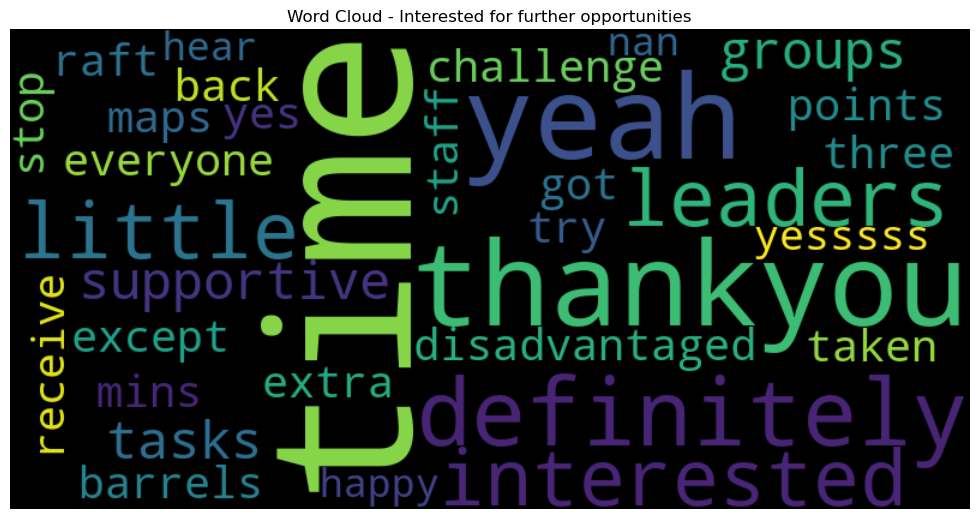

In [40]:
# Create word clouds for each category
for category in df['Category'].unique():
    category_text = ' '.join(df[df['Category'] == category]['Reviews'])
    create_wordcloud(category_text, f'Word Cloud - {category}')

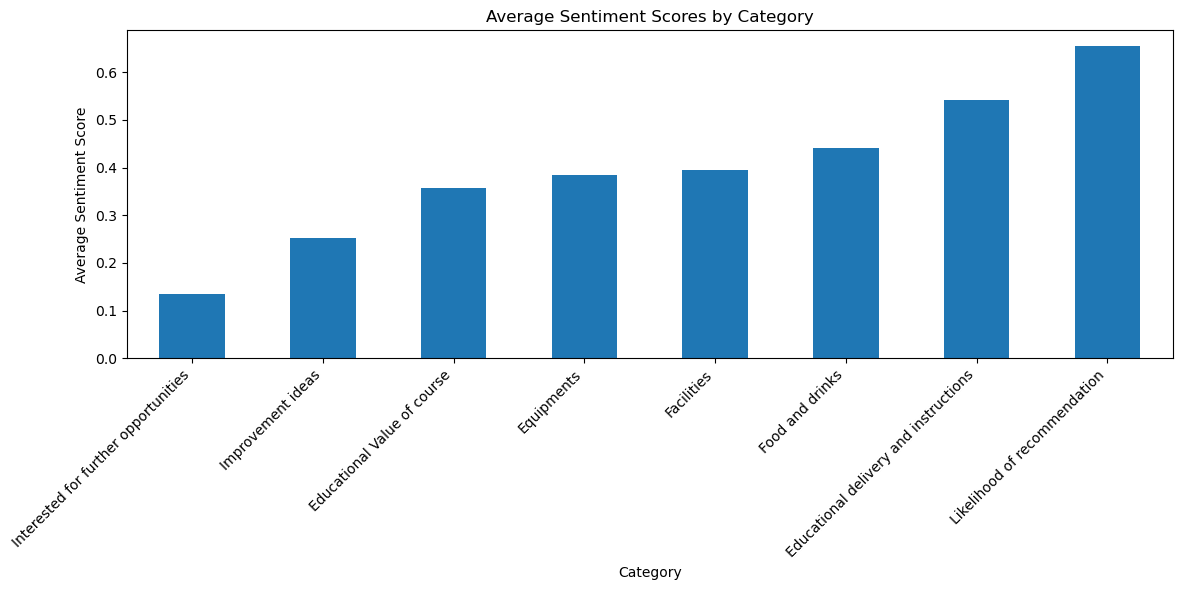

In [17]:
# Bar chart of average sentiment scores by category
plt.figure(figsize=(12, 6))
df.groupby('Category')['sentiment_scores'].mean().sort_values().plot(kind='bar')
plt.title('Average Sentiment Scores by Category')
plt.xlabel('Category')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

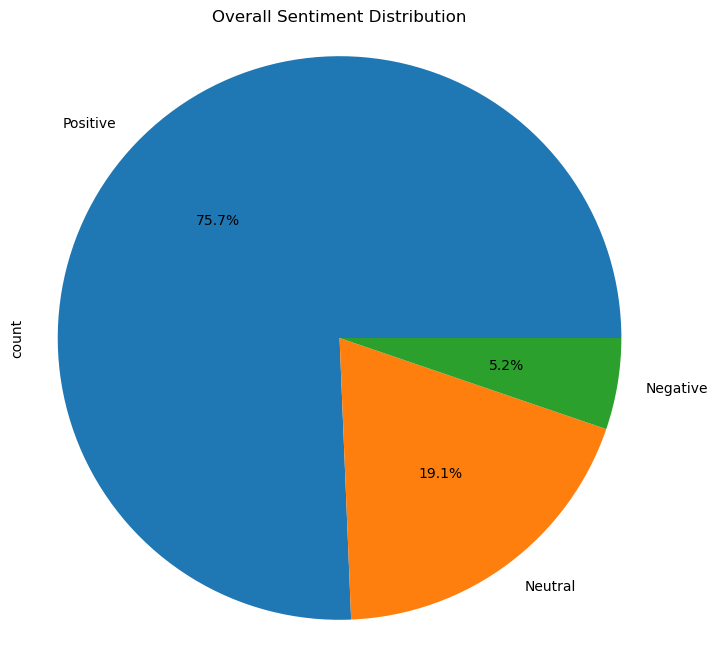

In [18]:
# Pie chart of overall sentiment distribution
plt.figure(figsize=(8, 8))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Overall Sentiment Distribution')
plt.axis('equal')
plt.show()

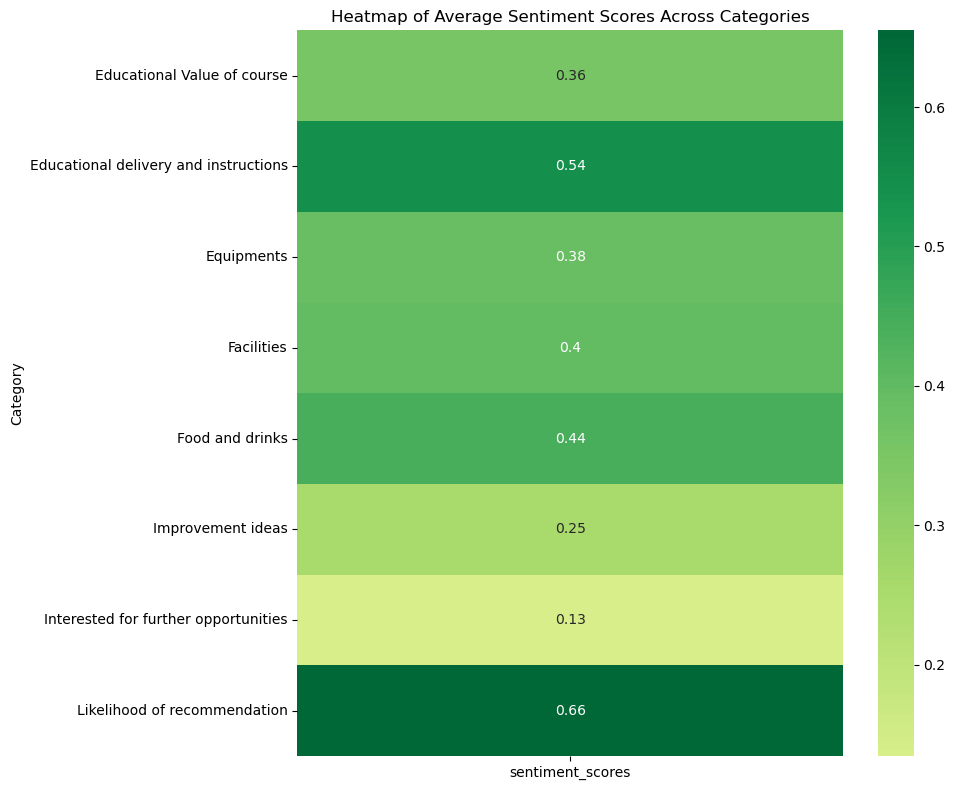

In [19]:
# Heatmap of sentiment scores across categories
pivot_df = df.pivot_table(values='sentiment_scores', index='Category', aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', center=0)
plt.title('Heatmap of Average Sentiment Scores Across Categories')
plt.tight_layout()
plt.show()

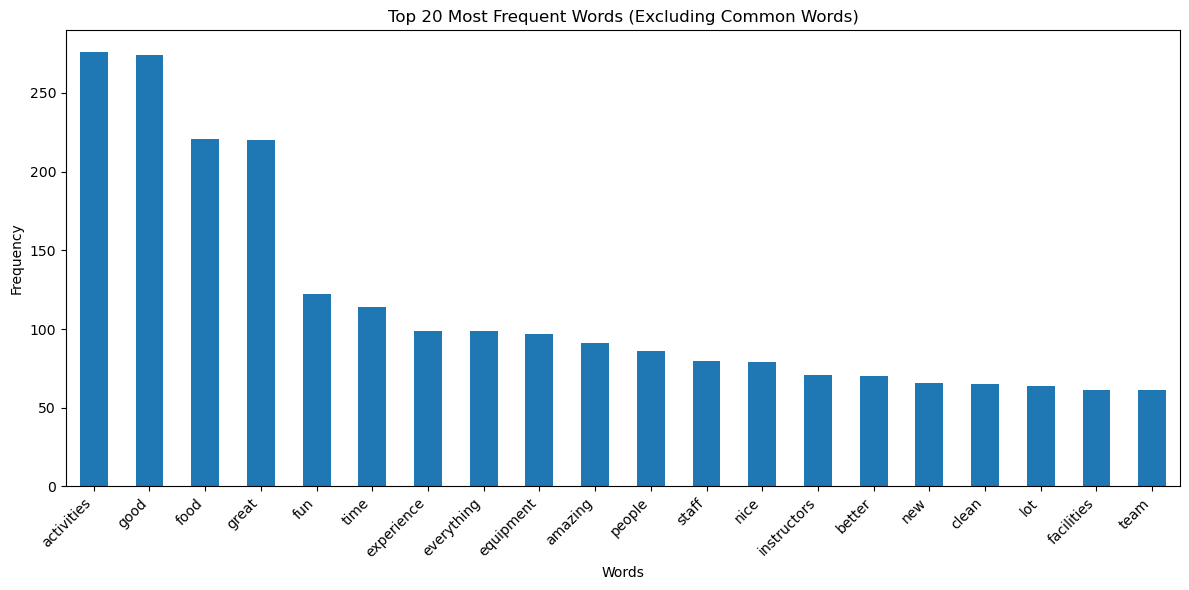

In [41]:
#Updated function to get word frequencies
def get_word_freq(text):
    words = word_tokenize(text.lower())
    words = [word for word in words if word.isalnum() and word not in custom_stop_words]
    return pd.Series(words).value_counts()
    
# Histogram of word frequencies
word_freq = get_word_freq(' '.join(df['Reviews']))
plt.figure(figsize=(12, 6))
word_freq[:20].plot(kind='bar')
plt.title('Top 20 Most Frequent Words (Excluding Common Words)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


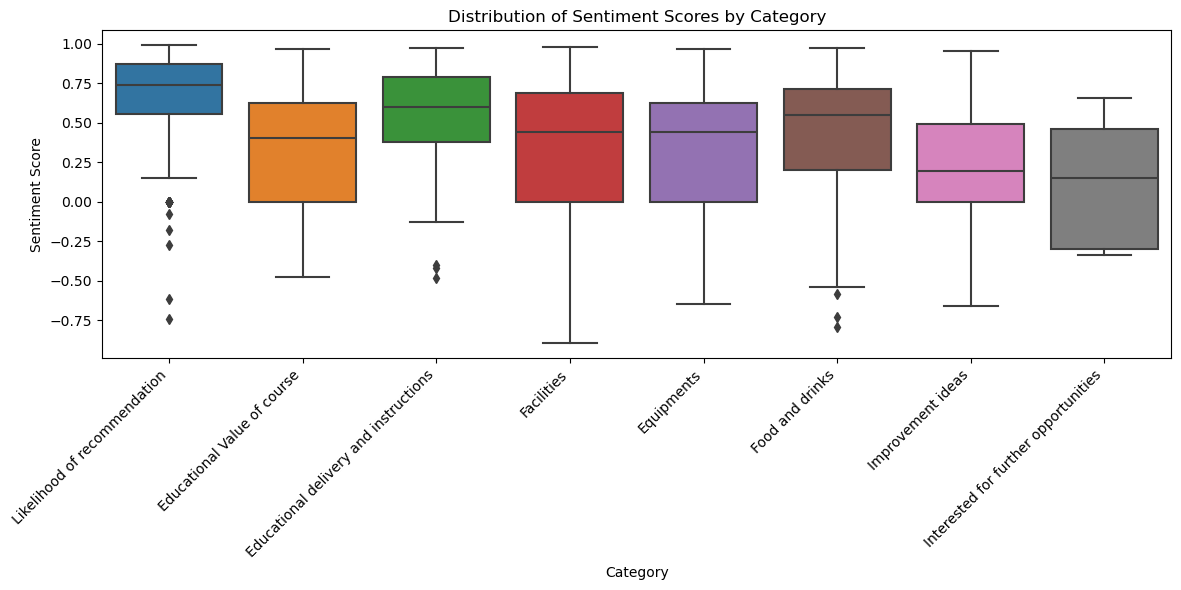

In [23]:
# Box plot of sentiment scores for each category
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='sentiment_scores', data=df)
plt.title('Distribution of Sentiment Scores by Category')
plt.xlabel('Category')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()